# Paper 3 — 01 · Refusal-direction probe

Builds the refusal-direction probe (METHOD_DESIGN §2) for one anchor model.
One-shot, ~10 GPU-minutes, no API cost. Probe artefacts feed every RD-DPO
training run downstream. Probe set is pre-registered: 100 toxic + 100 benign
Romanian prompts disjoint from train/dev/holdout.

**Inputs:** Paper 2 RoSafetyBench prompts (read from Drive).
**Outputs:** `data/probes/<short>/{block_directions.pt, block_scores.json,
selected_blocks.json, probe_set.jsonl, meta.json, score_curve.png}`.

**Runtime:** ~10 min on A100 for a 3-4B model; ~20 min for 7B.

In [8]:
%%capture
# Pinned versions match METHOD_DESIGN §4 + requirements.txt. Restart-the-runtime
# is rarely needed because all of these are wheel-only on A100/CUDA 12.
!pip install -U \
    'transformers>=4.51' \
    'accelerate>=1.1' \
    'peft>=0.13' \
    'torchao>=0.16' \
    'trl>=0.11' \
    'datasets>=3.0' \
    'bitsandbytes>=0.44' \
    huggingface_hub ipywidgets pyyaml -q


In [9]:
import os, json, gc, time, hashlib, math, sys
from pathlib import Path
from datetime import datetime
import torch

# --- Drive ---
from google.colab import drive
drive.mount("/content/drive")

# --- Paths ---
DRIVE_ROOT  = Path("/content/drive/MyDrive/PhD/paper3-alignment")
PAPER2_ROOT = Path("/content/drive/MyDrive/PhD/paper2-benchmark")

PROBE_DIR    = DRIVE_ROOT / "data" / "probes"
PREFS_DIR    = DRIVE_ROOT / "data" / "preferences"
SPLITS_DIR   = DRIVE_ROOT / "data" / "splits"
ADAPTERS_DIR = DRIVE_ROOT / "adapters"
RESULTS_DIR  = DRIVE_ROOT / "results"
LOGS_DIR     = DRIVE_ROOT / "logs"
FIG_DIR      = DRIVE_ROOT / "figures"
for d in [PROBE_DIR, PREFS_DIR, SPLITS_DIR, ADAPTERS_DIR, RESULTS_DIR, LOGS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Paper 2 reuse: judges, llm_judge, holdout splits ---
sys.path.insert(0, str(PAPER2_ROOT / "src"))

# --- A100 sanity + perf toggles ---
assert torch.cuda.is_available(), "GPU not available -- switch runtime to A100 GPU."
DEVICE_NAME = torch.cuda.get_device_name(0)
VRAM_GB = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU: {DEVICE_NAME}   VRAM: {VRAM_GB:.1f} GB   torch={torch.__version__}")
if "A100" not in DEVICE_NAME:
    print(f"WARNING: expected A100, got {DEVICE_NAME}. Re-tune BATCH_SIZE/grad-accum below.")

torch.set_float32_matmul_precision("high")          # TF32 for fp32 matmuls
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True               # autotune for fixed shapes

# --- HF / OpenRouter auth (set in Colab Secrets, not in code) ---
try:
    from google.colab import userdata
    if not os.environ.get("HF_TOKEN"):
        os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN") or ""
    if os.environ.get("HF_TOKEN"):
        from huggingface_hub import login as _hf_login
        _hf_login(os.environ["HF_TOKEN"], add_to_git_credential=False)
    if not os.environ.get("OPENROUTER_API_KEY"):
        os.environ["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY") or ""
except Exception as _e:
    print(f"(secrets not configured: {_e}; set HF_TOKEN / OPENROUTER_API_KEY in Colab secrets)")


def load_kwargs_for(family: str) -> dict:
    """A100-tuned dtype + attention impl per model family.

    Why bf16 everywhere: A100 has bf16 tensor cores at the same throughput as
    fp16, bf16 has the dynamic range of fp32 (no overflow on long sequences),
    and bf16 is the training dtype for all anchor families. Using fp16 here
    silently broke Gemma 3 in Paper 2 (953 empty-string outputs).
    """
    common = dict(torch_dtype=torch.bfloat16, device_map={"": 0})
    if family.startswith("gemma"):
        # Gemma 3 sliding-window attention is brittle with flash-attn-2.
        return {**common, "attn_implementation": "eager"}
    # PyTorch SDPA on A100 + bf16 is fast enough for our workloads.
    # flash-attn-2 was tried but its source-compile step costs ~15 min on
    # every cold Colab runtime, with negligible payoff for batch sizes <= 16.
    return {**common, "attn_implementation": "sdpa"}


# --- Paper 3 single-source-of-truth helpers ---
# short_of and family_of are imported from src/prompts.py so the
# notebook conventions stay aligned with notebook 02 (single point of
# change for path / family-name rules).
PROMPTS_SRC_DIR = DRIVE_ROOT / "src"
if not (PROMPTS_SRC_DIR / "prompts.py").exists():
    raise RuntimeError(
        f"src/prompts.py not found at {PROMPTS_SRC_DIR / 'prompts.py'}.\n"
        "Copy it from your local rosafety-align/src/prompts.py to that path "
        "in Drive, then re-run this cell."
    )
sys.path.insert(0, str(PROMPTS_SRC_DIR))
from prompts import short_of, family_of

print("Bootstrap done.")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: NVIDIA A100-SXM4-80GB   VRAM: 85.1 GB   torch=2.10.0+cu128
Bootstrap done.


## Configuration

`ANCHOR` is the only knob. Re-run once per anchor; cached artefacts are detected at the top of compute cells.

In [10]:
# Pick one anchor for this run.
# Anchors:    Qwen/Qwen2.5-3B-Instruct, meta-llama/Llama-3.2-3B-Instruct,
#             google/gemma-3-4b-it
# Scaling:    Qwen/Qwen2.5-{0.5B,1.5B,3B,7B}-Instruct
ANCHOR = "Qwen/Qwen2.5-3B-Instruct"

PROBE_SET_SIZE     = 200          # locked at submission; 100 tox + 100 ben
HIDDEN_BATCH_SIZE  = 8            # bf16 + last-position only -> small footprint
K_VALUES           = [1, 2, 4, 8]

short  = short_of(ANCHOR)
family = family_of(ANCHOR)
print(f"ANCHOR : {ANCHOR}")
print(f"family : {family}")
print(f"short  : {short}")

OUT = PROBE_DIR / short
OUT.mkdir(parents=True, exist_ok=True)
print(f"output : {OUT}")

ANCHOR : Qwen/Qwen2.5-3B-Instruct
family : qwen2.5
short  : qwen2.5-3b
output : /content/drive/MyDrive/PhD/paper3-alignment/data/probes/qwen2.5-3b


## Probe set (pre-registered, frozen)

Source: RoSafetyBench `toxicity` (harmful intents in Romanian) for the toxic
side, `overrefusal` (benign Romanian prompts that look superficially risky) for
the benign side. First run writes `probe_set.jsonl` to Drive and pins it; later
runs re-use it so layer ranking is comparable across anchors.

In [11]:
PROBE_SET_PATH = PROBE_DIR / "probe_set.jsonl"

if PROBE_SET_PATH.exists():
    probe_set = [json.loads(l) for l in open(PROBE_SET_PATH, encoding="utf-8")]
    print(f"Loaded frozen probe set ({len(probe_set)} prompts) from {PROBE_SET_PATH}")
else:
    import random
    rng = random.Random(0xC0FFEE)
    tox = [json.loads(l) for l in open(PAPER2_ROOT / "benchmark" / "expanded" / "toxicity.jsonl",   encoding="utf-8")]
    ben = [json.loads(l) for l in open(PAPER2_ROOT / "benchmark" / "expanded" / "overrefusal.jsonl", encoding="utf-8")]
    rng.shuffle(tox); rng.shuffle(ben)
    probe_set = (
        [{"id": x["id"], "text_ro": x["text_ro"], "y": "tox"} for x in tox[:100]] +
        [{"id": x["id"], "text_ro": x["text_ro"], "y": "ben"} for x in ben[:100]]
    )
    rng.shuffle(probe_set)
    with open(PROBE_SET_PATH, "w", encoding="utf-8") as f:
        for x in probe_set: f.write(json.dumps(x, ensure_ascii=False) + "\n")
    print(f"Constructed probe set ({len(probe_set)} prompts) -> {PROBE_SET_PATH}")

SHA   = hashlib.sha256(PROBE_SET_PATH.read_bytes()).hexdigest()[:16]
n_tox = sum(1 for x in probe_set if x["y"] == "tox")
n_ben = sum(1 for x in probe_set if x["y"] == "ben")
print(f"sha256[:16] = {SHA}   tox={n_tox}   ben={n_ben}")

Loaded frozen probe set (200 prompts) from /content/drive/MyDrive/PhD/paper3-alignment/data/probes/probe_set.jsonl
sha256[:16] = 448ded2b3f295e86   tox=100   ben=100


## Capture hidden states

We capture the residual-stream activation at the **last position of the
assistant prefix** (immediately before the first generated token). Single
forward pass per prompt with `output_hidden_states=True`, no generation.

In [12]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import numpy as np

OUT_FILE = OUT / "hidden_states.pt"
if OUT_FILE.exists():
    print(f"Cached hidden states found at {OUT_FILE}; skipping forward pass.")
    cache = torch.load(OUT_FILE)
    H, ys = cache["H"], cache["ys"]
else:
    tok = AutoTokenizer.from_pretrained(ANCHOR, padding_side="left")
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(ANCHOR, **load_kwargs_for(family))
    mdl.eval()

    formatted, ys = [], []
    for x in probe_set:
        text = tok.apply_chat_template(
            [{"role": "user", "content": x["text_ro"]}],
            tokenize=False, add_generation_prompt=True,
        )
        formatted.append(text); ys.append(x["y"])

    with torch.no_grad():
        ids = tok(formatted[:1], return_tensors="pt", padding=True,
                  truncation=True, max_length=1024).to(mdl.device)
        out = mdl(**ids, output_hidden_states=True, use_cache=False)
        n_blocks = len(out.hidden_states); d_model = out.hidden_states[0].shape[-1]
        print(f"n_blocks = {n_blocks}   d_model = {d_model}")

        H = torch.zeros(len(formatted), n_blocks, d_model, dtype=torch.float32)
        t0 = time.time()
        for i in range(0, len(formatted), HIDDEN_BATCH_SIZE):
            batch = formatted[i:i + HIDDEN_BATCH_SIZE]
            ids = tok(batch, return_tensors="pt", padding=True,
                      truncation=True, max_length=1024).to(mdl.device)
            out = mdl(**ids, output_hidden_states=True, use_cache=False)
            last_idx = ids["input_ids"].shape[1] - 1
            for layer_ix, hs in enumerate(out.hidden_states):
                H[i:i + len(batch), layer_ix, :] = hs[:, last_idx, :].float().cpu()
            if (i // HIDDEN_BATCH_SIZE) % 4 == 0:
                rate = (i + len(batch)) / max(time.time() - t0, 1e-6)
                print(f"  {i + len(batch):>4}/{len(formatted)}  {rate:.1f}/s")

    torch.save({"H": H, "ys": ys}, OUT_FILE)
    print(f"Saved hidden states -> {OUT_FILE}")
    del mdl, tok
    gc.collect(); torch.cuda.empty_cache()

Cached hidden states found at /content/drive/MyDrive/PhD/paper3-alignment/data/probes/qwen2.5-3b/hidden_states.pt; skipping forward pass.


## Score and rank blocks

`s_ℓ = ‖μ_tox − μ_ben‖₂ × |cos(d_ℓ, v_ℓ)|` where `d_ℓ` is the difference-in-means direction and `v_ℓ` is the principal component of toxic-class activations. High score = good separation **and** unidirectional toxic-class spread.

In [13]:
H_np = H.numpy()
y    = np.array([1 if v == "tox" else 0 for v in ys])
n_blocks, d_model = H_np.shape[1], H_np.shape[2]

block_directions = np.zeros((n_blocks, d_model), dtype=np.float32)
block_scores = []
for L in range(n_blocks):
    Ht = H_np[y == 1, L, :]; Hb = H_np[y == 0, L, :]
    mu_t = Ht.mean(axis=0);  mu_b = Hb.mean(axis=0)
    delta = mu_t - mu_b
    sep = float(np.linalg.norm(delta))
    d   = delta / max(sep, 1e-9)
    block_directions[L] = d.astype(np.float32)
    Ht_c = Ht - mu_t
    _, _, Vt = np.linalg.svd(Ht_c, full_matrices=False)
    cos = float(abs(d @ Vt[0]))
    block_scores.append({"layer": L, "separation": sep,
                         "unidirectionality": cos, "score": sep * cos})

ranked = sorted(block_scores, key=lambda r: r["score"], reverse=True)

# Two-sided cutoff (METHOD_DESIGN section 2.3):
#   - early: drop the first quarter of the network. Refusal directions
#     in early blocks are usually input-feature artefacts.
#   - late : drop the final 2 blocks. Refusal directions there are the
#     unembedding-adjacent region, not the internal refusal circuit
#     we are trying to identify. Empirically observed on Qwen-2.5-3B
#     and Llama-3.2-3B in the May 12 three-anchor probe sweep.
early_cutoff = max(1, n_blocks // 4)
late_cutoff  = n_blocks - 2
selected = {}
for k in K_VALUES:
    keep = []
    for r in ranked:
        if r["layer"] < early_cutoff: continue
        if r["layer"] >= late_cutoff: continue
        keep.append(r["layer"])
        if len(keep) == k: break
    selected[k] = sorted(keep)

top4 = float(np.mean([r["score"] for r in ranked[:4]]))
bot4 = float(np.mean([r["score"] for r in ranked[-4:]] or [1e-9]))
ratio = top4 / max(bot4, 1e-9)
print(f"separation range: {min(r['separation'] for r in block_scores):.3f}"
      f"  -> {max(r['separation'] for r in block_scores):.3f}")
print(f"top-4 / bottom-4 score ratio = {ratio:.2f}  (target >= 2.0)")
print(f"selected blocks: {selected}")


separation range: 0.000  -> 120.584
top-4 / bottom-4 score ratio = 555.81  (target >= 2.0)
selected blocks: {1: [34], 2: [33, 34], 4: [31, 32, 33, 34], 8: [26, 27, 28, 30, 31, 32, 33, 34]}


## Save artefacts

All written under `data/probes/<short>/`. Probe set + selected blocks ship with the public release.

/tmp/ipykernel_1916/2384015101.py:13: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "built_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",


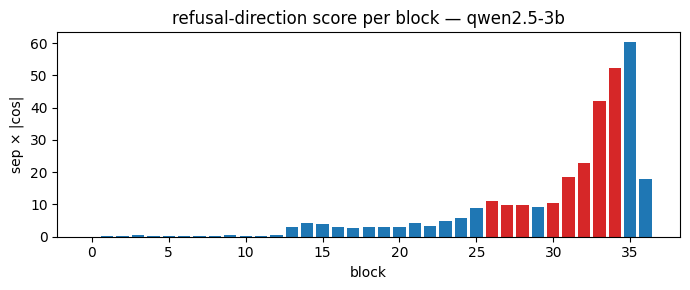


Done. Artefacts at /content/drive/MyDrive/PhD/paper3-alignment/data/probes/qwen2.5-3b


In [14]:
torch.save({"directions": torch.from_numpy(block_directions)}, OUT / "block_directions.pt")
(OUT / "block_scores.json").write_text(json.dumps(block_scores, indent=2))
(OUT / "selected_blocks.json").write_text(json.dumps(selected, indent=2))
(OUT / "meta.json").write_text(json.dumps({
    "anchor": ANCHOR, "short": short, "family": family,
    "n_blocks": n_blocks, "d_model": d_model,
    "probe_set_path": str(PROBE_SET_PATH), "probe_set_sha256_16": SHA,
    "n_tox": n_tox, "n_ben": n_ben,
    "early_cutoff_layer": early_cutoff,
    "score_top_bottom_ratio_4": ratio,
    "torch_version": torch.__version__,
    "device": DEVICE_NAME, "vram_gb": round(VRAM_GB, 1),
    "built_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",
}, indent=2))

import matplotlib.pyplot as plt
layers = [r["layer"] for r in block_scores]
scores = [r["score"] for r in block_scores]
plt.figure(figsize=(7, 3))
plt.bar(layers, scores)
for k_, blocks in selected.items():
    for L in blocks:
        plt.bar([L], [scores[L]], color="tab:red")
plt.title(f"refusal-direction score per block — {short}")
plt.xlabel("block"); plt.ylabel("sep × |cos|")
plt.tight_layout()
plt.savefig(OUT / "score_curve.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nDone. Artefacts at {OUT}")

## Mid-depth selection (depth band 0.55-0.80)

Same scoring metric as p3-01-rank, but the candidate window is
pinned to depth in [0.55, 0.80] -- the same band where Gemma's
successful e=6 run picked its blocks. Tests the hypothesis that
top-quarter selections on Qwen/Llama are why those anchors did
not train at LR=5e-6 with rebalanced 176-200 pairs.

Writes `selected_blocks_mid.json` -- separate from
`selected_blocks.json` -- so the original artefact is preserved
as a documented baseline.


In [15]:
# Mid-depth selection: rank by score, but only over blocks whose depth
# (layer / n_blocks) sits in [DEPTH_MIN, DEPTH_MAX]. Keeps the early
# bottom-quarter exclusion implicit in DEPTH_MIN; replaces the top-2
# late-cutoff with DEPTH_MAX.
DEPTH_MIN, DEPTH_MAX = 0.55, 0.80

def _depth(layer):
    return (layer + 1) / n_blocks  # 1-indexed depth so layer 0 -> 1/n_blocks

candidates = [r for r in ranked
              if DEPTH_MIN <= _depth(r["layer"]) <= DEPTH_MAX]
if len(candidates) < max(K_VALUES):
    raise ValueError(
        f"only {len(candidates)} blocks in depth band [{DEPTH_MIN}, {DEPTH_MAX}]; "
        f"need at least {max(K_VALUES)}. Widen the band for this anchor."
    )

selected_mid = {}
for k in K_VALUES:
    selected_mid[k] = sorted(r["layer"] for r in candidates[:k])

print(f"depth band : [{DEPTH_MIN}, {DEPTH_MAX}]")
print(f"candidates : {len(candidates)} blocks (depths "
      f"{[round(_depth(r['layer']), 2) for r in candidates[:8]]}{'...' if len(candidates) > 8 else ''})")
print(f"selected   : {selected_mid}")
print(f"depths of k=4 selection: "
      f"{[round(_depth(L), 2) for L in selected_mid[4]]}")

# Sanity check: scores for the k=4 mid-depth selection vs the original
# top-of-network selection. Lower is OK (we are trading score for
# trainability), but should still be well above the bottom-quartile.
sel_scores  = [next(r['score'] for r in ranked if r['layer'] == L) for L in selected_mid[4]]
orig_scores = [next(r['score'] for r in ranked if r['layer'] == L) for L in selected[4]]
print(f"\noriginal k=4 mean score: {sum(orig_scores)/len(orig_scores):.3f}")
print(f"mid-depth k=4 mean score: {sum(sel_scores)/len(sel_scores):.3f}")
print(f"ratio mid/original     : {(sum(sel_scores)/len(sel_scores)) / (sum(orig_scores)/len(orig_scores)):.3f}")

# Save
(OUT / "selected_blocks_mid.json").write_text(json.dumps(selected_mid, indent=2))
(OUT / "meta_mid.json").write_text(json.dumps({
    "anchor": ANCHOR, "short": short, "family": family,
    "depth_min": DEPTH_MIN, "depth_max": DEPTH_MAX,
    "selection_rule": "rank by score; restrict to depth band; take top-k",
    "n_candidates": len(candidates),
    "selected": selected_mid,
    "selected_depths": {str(k): [round(_depth(L), 2) for L in v]
                        for k, v in selected_mid.items()},
    "mean_score_top4_orig": sum(orig_scores) / len(orig_scores),
    "mean_score_top4_mid":  sum(sel_scores)  / len(sel_scores),
    "built_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",
}, indent=2))
print(f"\nwrote {OUT / 'selected_blocks_mid.json'} and meta_mid.json")


depth band : [0.55, 0.8]
candidates : 9 blocks (depths [0.73, 0.76, 0.78, 0.7, 0.68, 0.65, 0.59, 0.62]...)
selected   : {1: [26], 2: [26, 27], 4: [25, 26, 27, 28], 8: [21, 22, 23, 24, 25, 26, 27, 28]}
depths of k=4 selection: [0.7, 0.73, 0.76, 0.78]

original k=4 mean score: 33.879
mid-depth k=4 mean score: 9.949
ratio mid/original     : 0.294

wrote /content/drive/MyDrive/PhD/paper3-alignment/data/probes/qwen2.5-3b/selected_blocks_mid.json and meta_mid.json


/tmp/ipykernel_1916/1491458582.py:50: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "built_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",


## Batch run: probe artefacts for every anchor in `ANCHORS`

Self-contained. Loops over `ANCHORS` (imported from
`src/prompts.py`) and for each anchor emits the full probe artefact
set under `data/probes/<short>/`:

- `hidden_states.pt`
- `block_directions.pt`
- `block_scores.json`
- `selected_blocks.json` (top-of-network selection)
- `selected_blocks_mid.json` (depth-band 0.55-0.80 selection)
- `meta.json`, `meta_mid.json`, `score_curve.png`

Skips an anchor whose `selected_blocks_mid.json` already exists.
Re-uses the frozen `probe_set.jsonl` if present (built once on
first run from Paper 2's toxicity + overrefusal splits).

Operator workflow once this cell exists:
1. Run install + bootstrap.
2. Run only this batch cell.
Total: ~10 GPU-min for three anchors plus ~1 min cold-start each.


In [16]:
import gc, hashlib, json, time, random
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from prompts import ANCHORS  # single source of truth

PROBE_SET_SIZE     = 200
HIDDEN_BATCH_SIZE  = 8
K_VALUES           = [1, 2, 4, 8]
DEPTH_MIN, DEPTH_MAX = 0.55, 0.80


# ---------- shared probe set (anchor-independent) ----------

PROBE_SET_PATH = PROBE_DIR / "probe_set.jsonl"
PROBE_DIR.mkdir(parents=True, exist_ok=True)

if PROBE_SET_PATH.exists():
    probe_set = [json.loads(l) for l in open(PROBE_SET_PATH, encoding="utf-8")]
    print(f"Loaded frozen probe set ({len(probe_set)} prompts) from {PROBE_SET_PATH}")
else:
    rng = random.Random(0xC0FFEE)
    tox = [json.loads(l) for l in open(PAPER2_ROOT / "benchmark" / "expanded" / "toxicity.jsonl",   encoding="utf-8")]
    ben = [json.loads(l) for l in open(PAPER2_ROOT / "benchmark" / "expanded" / "overrefusal.jsonl", encoding="utf-8")]
    rng.shuffle(tox); rng.shuffle(ben)
    probe_set = (
        [{"id": x["id"], "text_ro": x["text_ro"], "y": "tox"} for x in tox[:100]] +
        [{"id": x["id"], "text_ro": x["text_ro"], "y": "ben"} for x in ben[:100]]
    )
    rng.shuffle(probe_set)
    with open(PROBE_SET_PATH, "w", encoding="utf-8") as f:
        for x in probe_set: f.write(json.dumps(x, ensure_ascii=False) + "\n")
    print(f"Constructed probe set ({len(probe_set)} prompts) -> {PROBE_SET_PATH}")

SHA   = hashlib.sha256(PROBE_SET_PATH.read_bytes()).hexdigest()[:16]
n_tox = sum(1 for x in probe_set if x["y"] == "tox")
n_ben = sum(1 for x in probe_set if x["y"] == "ben")
print(f"sha256[:16] = {SHA}   tox={n_tox}   ben={n_ben}")


def _process_one(anchor):
    short_a  = short_of(anchor)
    family_a = family_of(anchor)
    out_dir  = PROBE_DIR / short_a
    out_dir.mkdir(parents=True, exist_ok=True)

    if (out_dir / "selected_blocks_mid.json").exists() and (out_dir / "selected_blocks.json").exists():
        print(f"\n[{anchor}] both selection files present at {out_dir}; skipping.")
        return

    print(f"\n=== probing {anchor} -> {out_dir} ===")

    # ---- capture hidden states ----
    out_file = out_dir / "hidden_states.pt"
    if out_file.exists():
        print(f"  hidden states cached at {out_file}")
        cache = torch.load(out_file)
        H, ys = cache["H"], cache["ys"]
    else:
        tok_a = AutoTokenizer.from_pretrained(anchor, padding_side="left")
        if tok_a.pad_token is None: tok_a.pad_token = tok_a.eos_token
        mdl = AutoModelForCausalLM.from_pretrained(anchor, **load_kwargs_for(family_a))
        mdl.eval()

        formatted, ys = [], []
        for x in probe_set:
            text = tok_a.apply_chat_template(
                [{"role": "user", "content": x["text_ro"]}],
                tokenize=False, add_generation_prompt=True,
            )
            formatted.append(text); ys.append(x["y"])

        with torch.no_grad():
            ids = tok_a(formatted[:1], return_tensors="pt", padding=True,
                        truncation=True, max_length=1024).to(mdl.device)
            out = mdl(**ids, output_hidden_states=True, use_cache=False)
            n_blocks = len(out.hidden_states); d_model = out.hidden_states[0].shape[-1]
            print(f"  n_blocks={n_blocks}  d_model={d_model}")

            H = torch.zeros(len(formatted), n_blocks, d_model, dtype=torch.float32)
            t0 = time.time()
            for i in range(0, len(formatted), HIDDEN_BATCH_SIZE):
                batch = formatted[i:i + HIDDEN_BATCH_SIZE]
                ids = tok_a(batch, return_tensors="pt", padding=True,
                            truncation=True, max_length=1024).to(mdl.device)
                out = mdl(**ids, output_hidden_states=True, use_cache=False)
                last_idx = ids["input_ids"].shape[1] - 1
                for layer_ix, hs in enumerate(out.hidden_states):
                    H[i:i + len(batch), layer_ix, :] = hs[:, last_idx, :].float().cpu()

        torch.save({"H": H, "ys": ys}, out_file)
        print(f"  saved hidden states -> {out_file}")
        del mdl, tok_a; gc.collect(); torch.cuda.empty_cache()

    # ---- score and rank ----
    H_np = H.numpy()
    y    = np.array([1 if v == "tox" else 0 for v in ys])
    n_blocks, d_model = H_np.shape[1], H_np.shape[2]

    block_directions = np.zeros((n_blocks, d_model), dtype=np.float32)
    block_scores = []
    for L in range(n_blocks):
        Ht = H_np[y == 1, L, :]; Hb = H_np[y == 0, L, :]
        mu_t = Ht.mean(axis=0);  mu_b = Hb.mean(axis=0)
        delta = mu_t - mu_b
        sep = float(np.linalg.norm(delta))
        d   = delta / max(sep, 1e-9)
        block_directions[L] = d.astype(np.float32)
        Ht_c = Ht - mu_t
        _, _, Vt = np.linalg.svd(Ht_c, full_matrices=False)
        cos = float(abs(d @ Vt[0]))
        block_scores.append({"layer": L, "separation": sep,
                             "unidirectionality": cos, "score": sep * cos})

    ranked = sorted(block_scores, key=lambda r: r["score"], reverse=True)

    # ---- top-of-network selection (existing rule) ----
    early_cutoff = max(1, n_blocks // 4)
    late_cutoff  = n_blocks - 2
    selected = {}
    for k in K_VALUES:
        keep = []
        for r in ranked:
            if r["layer"] < early_cutoff: continue
            if r["layer"] >= late_cutoff: continue
            keep.append(r["layer"])
            if len(keep) == k: break
        selected[k] = sorted(keep)

    top4 = float(np.mean([r["score"] for r in ranked[:4]]))
    bot4 = float(np.mean([r["score"] for r in ranked[-4:]] or [1e-9]))
    ratio = top4 / max(bot4, 1e-9)
    print(f"  top4/bot4 score ratio: {ratio:.2f}  (target >= 2.0)")
    print(f"  top-of-network selection: {selected}")

    # ---- mid-depth selection ----
    def _depth(L): return (L + 1) / n_blocks
    candidates = [r for r in ranked if DEPTH_MIN <= _depth(r["layer"]) <= DEPTH_MAX]
    if len(candidates) < max(K_VALUES):
        raise ValueError(
            f"only {len(candidates)} blocks in depth band [{DEPTH_MIN}, {DEPTH_MAX}]; "
            f"need {max(K_VALUES)} for k_max. Widen the band for {anchor}."
        )
    selected_mid = {}
    for k in K_VALUES:
        selected_mid[k] = sorted(r["layer"] for r in candidates[:k])
    print(f"  mid-depth selection: {selected_mid}")
    print(f"  mid k=4 depths: {[round(_depth(L), 2) for L in selected_mid[4]]}")
    sel_scores  = [next(r['score'] for r in ranked if r['layer'] == L) for L in selected_mid[4]]
    orig_scores = [next(r['score'] for r in ranked if r['layer'] == L) for L in selected[4]]
    mid_orig_ratio = (sum(sel_scores)/len(sel_scores)) / max(sum(orig_scores)/len(orig_scores), 1e-9)
    print(f"  mid/orig k=4 score ratio: {mid_orig_ratio:.3f}")

    # ---- save ----
    torch.save({"directions": torch.from_numpy(block_directions)}, out_dir / "block_directions.pt")
    (out_dir / "block_scores.json").write_text(json.dumps(block_scores, indent=2))
    (out_dir / "selected_blocks.json").write_text(json.dumps(selected, indent=2))
    (out_dir / "selected_blocks_mid.json").write_text(json.dumps(selected_mid, indent=2))
    (out_dir / "meta.json").write_text(json.dumps({
        "anchor": anchor, "short": short_a, "family": family_a,
        "n_blocks": n_blocks, "d_model": d_model,
        "probe_set_path": str(PROBE_SET_PATH), "probe_set_sha256_16": SHA,
        "n_tox": n_tox, "n_ben": n_ben,
        "early_cutoff_layer": early_cutoff,
        "score_top_bottom_ratio_4": ratio,
        "torch_version": torch.__version__,
        "device": DEVICE_NAME, "vram_gb": round(VRAM_GB, 1),
        "built_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",
    }, indent=2))
    (out_dir / "meta_mid.json").write_text(json.dumps({
        "anchor": anchor, "short": short_a, "family": family_a,
        "depth_min": DEPTH_MIN, "depth_max": DEPTH_MAX,
        "selection_rule": "rank by sep*|cos|; restrict to depth band; take top-k",
        "n_candidates": len(candidates),
        "selected": selected_mid,
        "selected_depths": {str(k): [round(_depth(L), 2) for L in v]
                            for k, v in selected_mid.items()},
        "mean_score_top4_orig": sum(orig_scores) / len(orig_scores),
        "mean_score_top4_mid":  sum(sel_scores)  / len(sel_scores),
        "built_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",
    }, indent=2))

    # score curve
    import matplotlib.pyplot as plt
    layers = [r["layer"] for r in block_scores]
    scores = [r["score"] for r in block_scores]
    plt.figure(figsize=(7, 3))
    plt.bar(layers, scores)
    for L in selected[4]:
        plt.bar([L], [scores[L]], color="tab:red", label="top-of-net" if L == selected[4][0] else None)
    for L in selected_mid[4]:
        plt.bar([L], [scores[L]], color="tab:orange", label="mid-depth" if L == selected_mid[4][0] else None)
    plt.title(f"refusal-direction score per block - {short_a}")
    plt.xlabel("block"); plt.ylabel("sep x |cos|")
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.savefig(out_dir / "score_curve.png", dpi=120, bbox_inches="tight")
    plt.close()

    print(f"  wrote artefacts -> {out_dir}")


for anchor in ANCHORS:
    _process_one(anchor)
print("\nbatch probe done.")


Loaded frozen probe set (200 prompts) from /content/drive/MyDrive/PhD/paper3-alignment/data/probes/probe_set.jsonl
sha256[:16] = 448ded2b3f295e86   tox=100   ben=100

[Qwen/Qwen2.5-3B-Instruct] both selection files present at /content/drive/MyDrive/PhD/paper3-alignment/data/probes/qwen2.5-3b; skipping.

=== probing meta-llama/Llama-3.2-3B-Instruct -> /content/drive/MyDrive/PhD/paper3-alignment/data/probes/llama-3.2-3b ===
  hidden states cached at /content/drive/MyDrive/PhD/paper3-alignment/data/probes/llama-3.2-3b/hidden_states.pt
  top4/bot4 score ratio: 72.33  (target >= 2.0)
  top-of-network selection: {1: [26], 2: [25, 26], 4: [23, 24, 25, 26], 8: [13, 14, 15, 21, 23, 24, 25, 26]}
  mid-depth selection: {1: [21], 2: [15, 21], 4: [15, 16, 20, 21], 8: [15, 16, 17, 18, 19, 20, 21, 22]}
  mid k=4 depths: [0.55, 0.59, 0.72, 0.76]
  mid/orig k=4 score ratio: 0.171


/tmp/ipykernel_1916/2163708712.py:172: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "built_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",
/tmp/ipykernel_1916/2163708712.py:184: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "built_at": datetime.utcnow().isoformat(timespec="seconds") + "Z",


  wrote artefacts -> /content/drive/MyDrive/PhD/paper3-alignment/data/probes/llama-3.2-3b

=== probing google/gemma-3-4b-it -> /content/drive/MyDrive/PhD/paper3-alignment/data/probes/gemma-3-4b ===
  hidden states cached at /content/drive/MyDrive/PhD/paper3-alignment/data/probes/gemma-3-4b/hidden_states.pt
  top4/bot4 score ratio: 2697.73  (target >= 2.0)
  top-of-network selection: {1: [25], 2: [25, 26], 4: [24, 25, 26, 27], 8: [14, 16, 23, 24, 25, 26, 27, 28]}
  mid-depth selection: {1: [25], 2: [25, 26], 4: [24, 25, 26, 27], 8: [19, 21, 22, 23, 24, 25, 26, 27]}
  mid k=4 depths: [0.71, 0.74, 0.77, 0.8]
  mid/orig k=4 score ratio: 1.000
  wrote artefacts -> /content/drive/MyDrive/PhD/paper3-alignment/data/probes/gemma-3-4b

batch probe done.
